установка библиотек

In [1]:
!pip install -q numpy pandas scikit-learn matplotlib tensorflow

загрузка данных

In [ ]:
from google.colab import files

uploaded = files.upload()

импорт библиотек


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch, butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

чтение csv

In [ ]:
def load_eeg_csv(path, label):
    df = pd.read_csv(path, sep=';', decimal=',')
    df.columns = ['time', 'EEG']
    df['label'] = label
    return df

apples = load_eeg_csv('apples.csv', 'apple')
cakes = load_eeg_csv('cakes.csv', 'cake')
noise = load_eeg_csv('noise.csv', 'noise')

print('apples:', apples.shape)
print('cakes :', cakes.shape)
print('noise :', noise.shape)

display(apples.head())
display(cakes.head())
display(noise.head())

apples: (34036, 3)
cakes : (43587, 3)
noise : (26300, 3)


,time,EEG,label
0,0.000,374.621612,apple
1,0.005,387.702468,apple
2,0.010,400.133047,apple
3,0.015,412.765059,apple
4,0.020,421.996603,apple


,time,EEG,label
0,0.000,359.034961,cake
1,0.005,353.056212,cake
2,0.010,347.879992,cake
3,0.015,346.402668,cake
4,0.020,347.026699,cake


,time,EEG,label
0,0.000,-9.631973e-22,noise
1,0.005,-1.340165e-06,noise
2,0.010,-2.931149e-04,noise
3,0.015,-9.891526e-04,noise
4,0.020,-1.883532e-03,noise


первичная визуализация сигнала

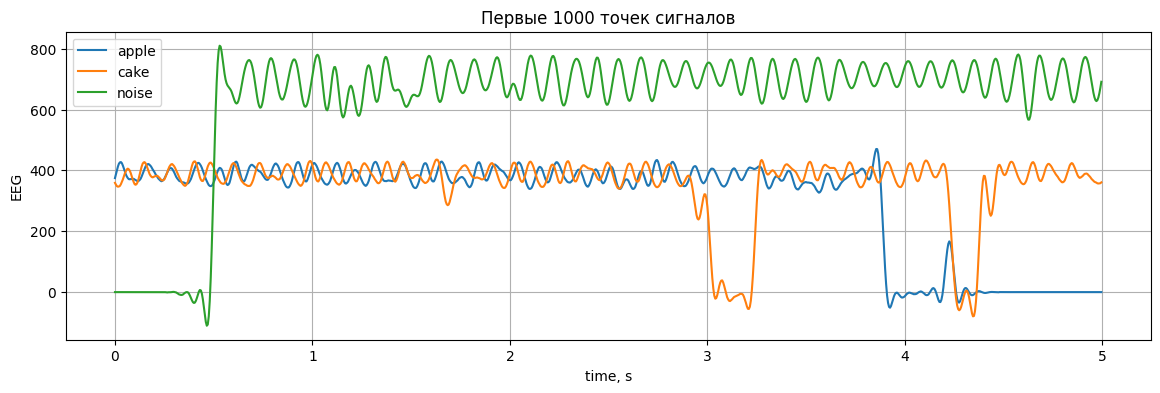

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(apples['time'][:1000], apples['EEG'][:1000], label='apple')
plt.plot(cakes['time'][:1000], cakes['EEG'][:1000], label='cake')
plt.plot(noise['time'][:1000], noise['EEG'][:1000], label='noise')
plt.legend()
plt.title('Первые 1000 точек сигналов')
plt.xlabel('time, s')
plt.ylabel('EEG')
plt.grid(True)
plt.show()

спектры до фильтрации

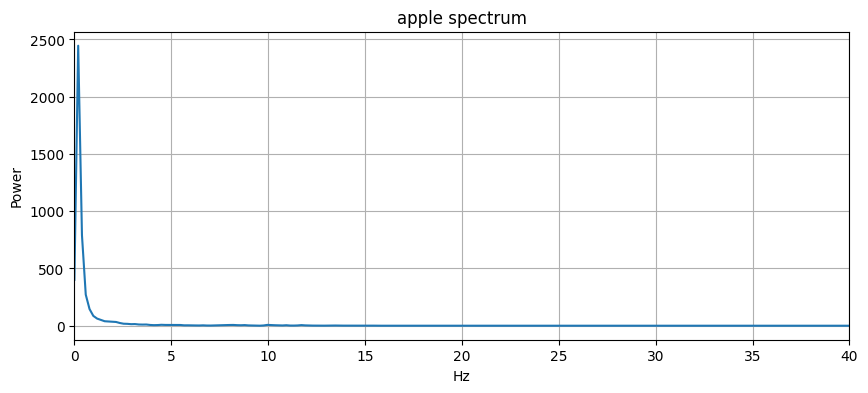

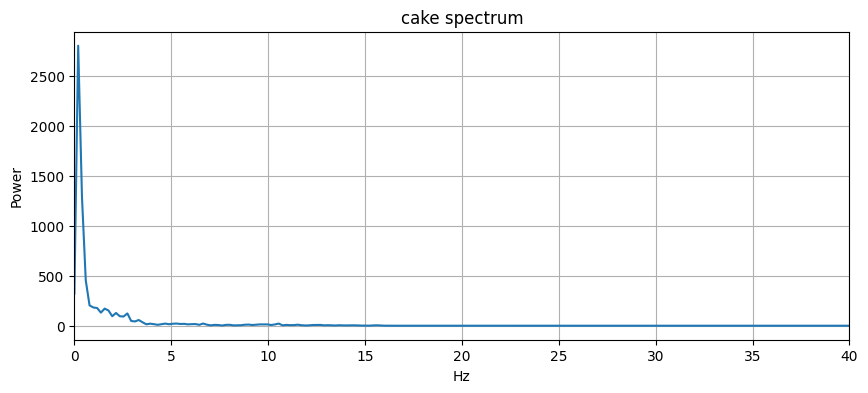

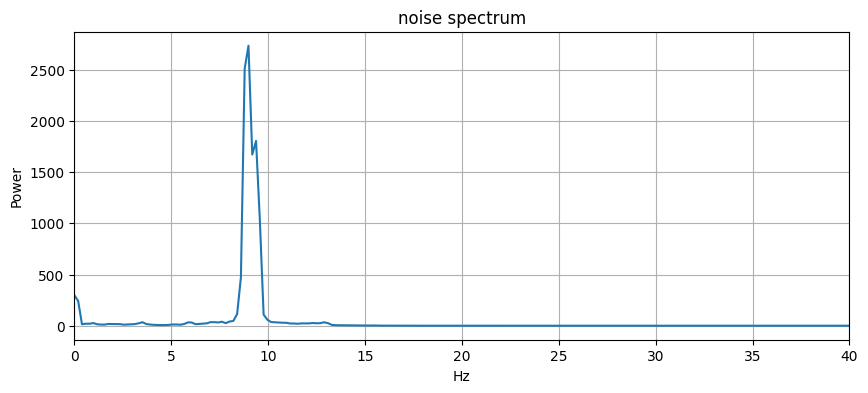

In [ ]:
FS = 200  # частота дискретизации

def plot_spectrum(signal, title):
    f, pxx = welch(signal, fs=FS, nperseg=1024)
    plt.figure(figsize=(10, 4))
    plt.plot(f, pxx)
    plt.title(title)
    plt.xlabel("Hz")
    plt.ylabel("Power")
    plt.xlim(0, 40)
    plt.grid(True)
    plt.show()

plot_spectrum(apples['EEG'].values, 'apple spectrum')
plot_spectrum(cakes['EEG'].values, 'cake spectrum')
plot_spectrum(noise['EEG'].values, 'noise spectrum')

полосовой фильтр

In [ ]:
def bandpass_filter(signal, low=1, high=40, fs=200, order=4):
    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

фильтрация сигналов

In [ ]:
apples_f = bandpass_filter(apples['EEG'].values)
cakes_f = bandpass_filter(cakes['EEG'].values)
noise_f = bandpass_filter(noise['EEG'].values)

спектры после фильтрации

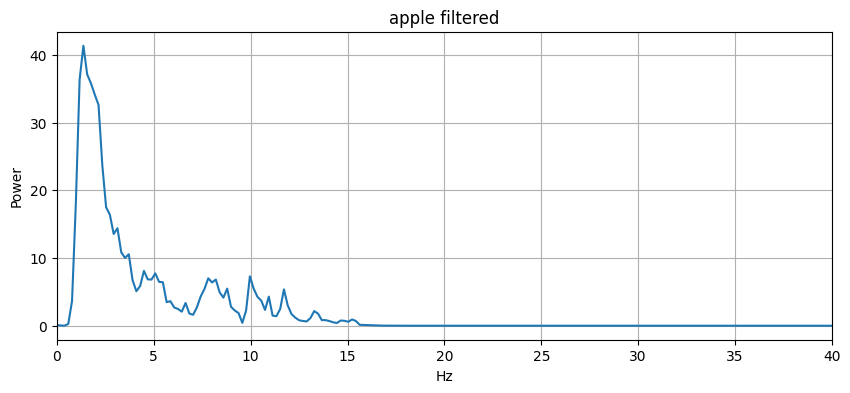

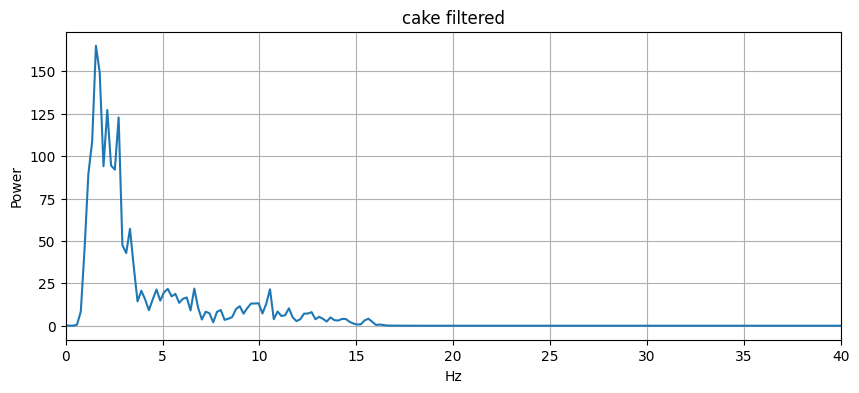

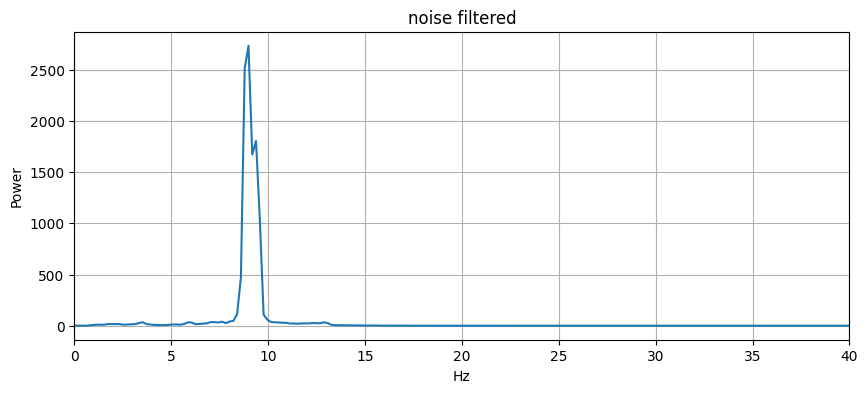

In [ ]:
plot_spectrum(apples_f, 'apple filtered')
plot_spectrum(cakes_f, 'cake filtered')
plot_spectrum(noise_f, 'noise filtered')

признаки по диапазонам ээг

In [ ]:
def band_features(signal, fs=200):
    freqs, psd = welch(signal, fs=fs, nperseg=400)

    delta = psd[(freqs >= 1) & (freqs < 4)].mean()
    theta = psd[(freqs >= 4) & (freqs < 8)].mean()
    alpha = psd[(freqs >= 8) & (freqs < 12)].mean()
    beta  = psd[(freqs >= 12) & (freqs < 30)].mean()

    return [delta, theta, alpha, beta]

создание датасета из окон

In [ ]:
WINDOW = 400
STEP = 200

def make_band_dataset(signal, label):
    X = []
    y = []

    for start in range(0, len(signal) - WINDOW, STEP):
        segment = signal[start:start + WINDOW]
        feats = band_features(segment, fs=FS)
        X.append(feats)
        y.append(label)

    return np.array(X), np.array(y)

сбор финального датасета

In [ ]:
Xa, ya = make_band_dataset(apples_f, 0)
Xc, yc = make_band_dataset(cakes_f, 1)
Xn, yn = make_band_dataset(noise_f, 2)

X_band = np.concatenate([Xa, Xc, Xn])
y_band = np.concatenate([ya, yc, yn])

print("Форма X_band:", X_band.shape)
print("Форма y_band:", y_band.shape)

class_names = ['apple', 'cake', 'noise']
print("Метки классов:")
for i, name in enumerate(class_names):
    print(i, '->', name)

Форма X_band: (515, 4)
Форма y_band: (515,)
Метки классов:
0 -> apple
1 -> cake
2 -> noise


обучение модели

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X_band, y_band,
    test_size=0.2,
    random_state=42,
    stratify=y_band
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(Xtrain, ytrain)
pred = model.predict(Xtest)

метрики

In [ ]:
print("Accuracy:", accuracy_score(ytest, pred))
print("\nClassification report:")
print(classification_report(ytest, pred))
print("Confusion matrix:")
print(confusion_matrix(ytest, pred))

Accuracy: 0.6601941747572816

Classification report:
              precision    recall  f1-score   support

           0       0.43      0.09      0.15        34
           1       0.56      0.91      0.69        43
           2       1.00      1.00      1.00        26

    accuracy                           0.66       103
   macro avg       0.66      0.67      0.61       103
weighted avg       0.63      0.66      0.59       103

Confusion matrix:
[[ 3 31  0]
 [ 4 39  0]
 [ 0  0 26]]


вывод

In [ ]:
print("Вывод эксперимента:")
print("Класс noise отделяется хорошо, так как его спектр существенно отличается.")
print("Классы apple и cake различаются слабо.")
print("Это означает, что по одноканальной ЭЭГ в данном эксперименте модель")
print("лучше распознаёт наличие/отсутствие сигнала, чем конкретный мысленный образ.")

Вывод эксперимента:
Класс noise отделяется хорошо, так как его спектр существенно отличается.
Классы apple и cake различаются слабо.
Это означает, что по одноканальной ЭЭГ в данном эксперименте модель
лучше распознаёт наличие/отсутствие сигнала, чем конкретный мысленный образ.
